# 33회 ADP 복원 

# 기계학습 (60점)

## 데이터 설명
- 데이터 출처 : https://archive.ics.uci.edu/ml/datasets/HCV+data 후처리
- 데이터 링크 : ./data/p1.csv
- 데이터 설명 : 혈액수치 데이터, 간염 정도에 따른

Category (종속변수) 
- 0: 정상
- 1,2,3 (간염 정도, 심각성 : 3>2>1, 3은 간경화)


In [4]:
import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
# 경고(Warning)만 끄고, 오류(Exception)는 그대로 출력
warnings.filterwarnings('ignore')

In [5]:
import pandas as pd 
df = pd.read_csv("https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p1.csv")
df.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=B,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=B,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=B,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=B,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=B,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [6]:
# 데이터 셋 확인
print(df.info())
print("\n 두개의 범주형 변수(Category,Sex)와 수치형 변수(Age, ALB, ...)로 이루어져 있는 데이터셋이다.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  608 non-null    object 
 1   Age       608 non-null    int64  
 2   Sex       608 non-null    object 
 3   ALB       607 non-null    float64
 4   ALP       590 non-null    float64
 5   ALT       607 non-null    float64
 6   AST       608 non-null    float64
 7   BIL       608 non-null    float64
 8   CHE       608 non-null    float64
 9   CHOL      598 non-null    float64
 10  CREA      608 non-null    float64
 11  GGT       608 non-null    float64
 12  PROT      607 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 61.9+ KB
None

 두개의 범주형 변수(Category,Sex)와 수치형 변수(Age, ALB, ...)로 이루어져 있는 데이터셋이다.


In [7]:
# 데이터 기초통계량 
display(df.describe(include='object')) # 범주형변수
display(df.describe().T)  # 수치형 변수

,Category,Sex
count,608,608
unique,4,2
top,0=B,m
freq,533,371


,count,mean,std,min,25%,50%,75%,max
Age,608.0,47.291118,9.992705,19.00,39.00,47.00,54.000,77.00
ALB,607.0,41.818781,5.406717,20.00,39.00,42.00,45.250,82.20
ALP,590.0,67.821017,25.274423,11.30,52.50,66.00,79.525,416.60
ALT,607.0,27.601318,21.227539,0.90,16.40,23.00,32.750,258.00
AST,608.0,34.369408,32.622442,12.00,21.60,25.85,32.800,324.00
BIL,608.0,11.474013,19.770558,1.80,5.30,7.30,11.300,254.00
CHE,608.0,8.204885,2.168400,1.42,6.95,8.27,9.585,16.41
CHOL,598.0,5.378829,1.119394,1.43,4.62,5.30,6.075,9.67
CREA,608.0,81.513158,49.720652,8.00,68.00,77.00,88.000,1079.10
GGT,608.0,38.243914,51.953220,4.50,15.70,23.25,39.200,650.90



 <범주형 변수 분포 확인> 


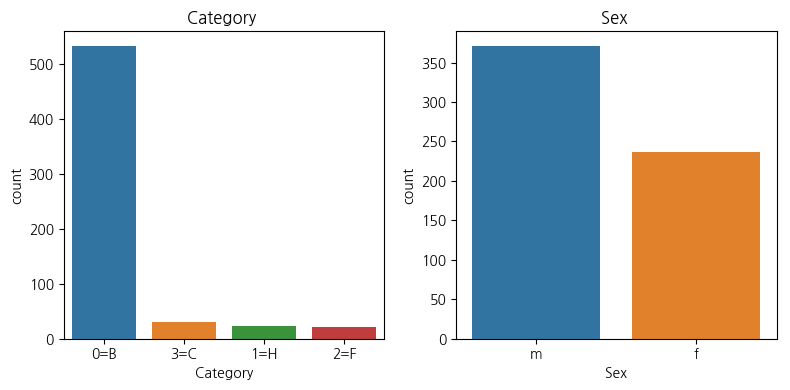

종속변수 Category에서 클래스 0=B에 빈도수가 대부분 몰려있으며, 이는 불균형 데이터임을 확인 할 수 있다.


In [8]:
# 분포 확인
print("\n <범주형 변수 분포 확인> ")
cate_df = df.loc[:,df.dtypes == 'object'] 
categorical_cols = cate_df.columns
plt.figure(figsize=(8,4))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    sns.countplot(data=cate_df, x=col, \
                  order=cate_df[col].value_counts().index)
    plt.title(f"{col} ")
    plt.tight_layout()
plt.show()
print("종속변수 Category에서 클래스 0=B에 빈도수가 대부분 몰려있으며, 이는 불균형 데이터임을 확인 할 수 있다.")


 <수치형 변수 분포 확인> 


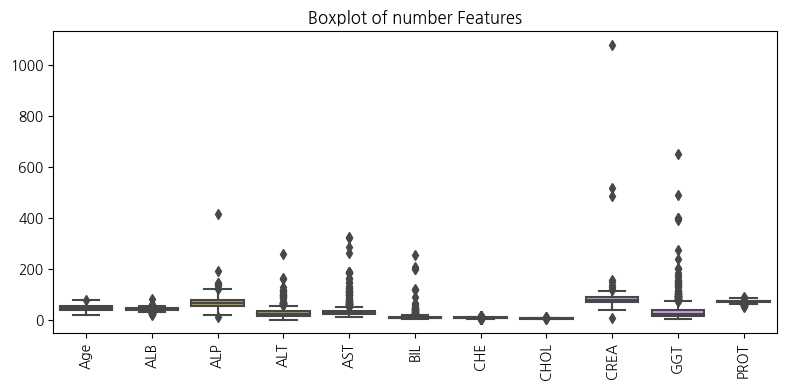

수치형 변수들에 이상치가 매우 많음을 알 수 있다. 하지만 이상치가 간염 정도에 중요한 데이터일 수 있으므로 제거하지 않는다.


In [9]:
print("\n <수치형 변수 분포 확인> ")
num_df = df.loc[:, df.dtypes != 'object']
numerical_cols = num_df.columns
plt.figure(figsize = (8,4))
sns.boxplot(data = num_df) # data
plt.xticks(rotation=90) # ← !
plt.title("Boxplot of number Features")
plt.tight_layout()
plt.show()
print("수치형 변수들에 이상치가 매우 많음을 알 수 있다. 하지만 이상치가 간염 정도에 중요한 데이터일 수 있으므로 제거하지 않는다.")

In [11]:
print("\n <결측치 확인>")
display(df.isnull().mean().to_frame().T)
print("변수 ALB, ALP, ALT, CHOL에 결측치가 있지만 모두 5% 미만으로 존재한다.")


 <결측치 확인>


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0.0,0.0,0.0,0.001645,0.029605,0.001645,0.0,0.0,0.0,0.016447,0.0,0.0,0.001645


변수 ALB, ALP, ALT, CHOL에 결측치가 있다.


## 1-1  결측치 처리 방안 2개 제시하고, 처리 전후 비교 및 더 나은 방안 선택하여 전처리 완료

1. 중앙값으로 대치 : 수치형 변수에서 이상치에 강한 대표값
- 장점 : 간단하고 빠르다, 이상치에 강하다. 
- 단점 : 변수 간 관계 무시, 정확도 저하 가능성 있다. 범주별로 다르게 처리하고 싶을 때는 추가 작업이 필요하다. 
-   
2. knnImputer (모델링하여 결측값 대치): 결측값이 있는 행을 결측값이 없는 이웃 샘플(k개)과 비교하여 이웃들의 평균값으로 결측치 대치한다. 
 - 장점 : 변수 간 상관관계를 반영하고, 비선형 구조에도 효과적이다. 범주형에도 응용이 가능하다.
 - 단점 : 이상치에 민감하고 계산량이 많다. 스케일이 필요하다(정규화)- 거리기반 모델이므로

In [12]:
# df_rm = df.dropna()  # 만약 결측치 제거일 시. 
# df_rm.info()

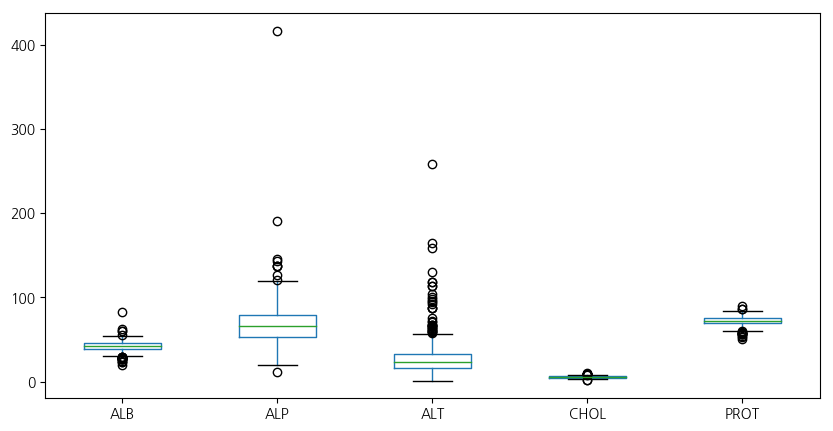

In [13]:
cols = ['ALB', 'ALP', 'ALT', 'CHOL', 'PROT']

df.loc[:,cols].plot(kind='box',figsize=(10,5)) # 이상치 많음 
plt.show()

In [18]:
(df.shape[0]- df.dropna().shape[0])/df.shape[0] 
# 결측치를 제거하게 되면 약 4% 정도 삭제하게 된다. 이는 삭제해도 분석 결과에 큰 영향 없을 정도의 무리 없는 비율이라 판단하여 제거한다.

0.04276315789473684

## 모델링하여 결측값 대치 

In [21]:
df = df.dropna()
df.isnull().sum().to_frame().T

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
df_num = df.loc[:, df.dtypes != 'object'] # 이상치에 민감하다.

In [12]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors = 3)
df_knn = imputer.fit_transform(df_num)
df_knn = pd.DataFrame(df_knn, columns = df_num.columns)

cate_df = df.loc[:,df.dtypes == 'object']
df_knn = pd.concat([df_knn,cate_df],axis =1)

df_knn.isna().sum()

Age         0
ALB         0
ALP         0
ALT         0
AST         0
BIL         0
CHE         0
CHOL        0
CREA        0
GGT         0
PROT        0
Category    0
Sex         0
dtype: int64

In [14]:
# 결측 컬럼 추출
isnull = df.isnull().sum()
isnull = isnull[isnull > 0].to_frame(name='결측치수')
isnull['타입'] = df.dtypes[isnull.index]
null_cols = isnull.index.tolist()

# 통계 계산 함수
def get_stats(df, cols):
    stats = df[cols].describe().T[['mean', 'std']].round(2)
    return stats.rename(columns={'mean': '평균', 'std': '표준편차'})

# 각 버전의 통계
orig_stats = get_stats(df, null_cols)
med_stats = get_stats(df_med, null_cols)
knn_stats = get_stats(df_knn, null_cols)

# 통합
result = pd.concat([
    isnull,
    orig_stats,
    med_stats,
    knn_stats
], axis=1)

# 컬럼명 정리
result.columns = [
    '결측치수', '타입',
    '전처리 전 평균', '전처리 전 표준편차',
    '중앙값 대치 평균', '중앙값 대치 표준편차',
    'KNN 대치 평균', 'KNN 대치 표준편차'
]

# 출력
display(result)

,결측치수,타입,전처리 전 평균,전처리 전 표준편차,중앙값 대치 평균,중앙값 대치 표준편차,KNN 대치 평균,KNN 대치 표준편차
ALB,1,float64,41.82,5.41,41.82,5.40,41.81,5.40
ALP,18,float64,67.82,25.27,67.77,24.90,67.87,24.97
ALT,1,float64,27.60,21.23,27.59,21.21,27.59,21.21
CHOL,10,float64,5.38,1.12,5.38,1.11,5.39,1.12
PROT,1,float64,72.25,4.93,72.25,4.93,72.25,4.93


## 1-2 이상치를 확인하고 처리 여부 판단 후 작업

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
df.drop(columns =['Category','Sex']).plot(kind='box',figsize=(10,5))
plt.show()
print('''
컬럼 별 이상치가 존재하는 것으로 보인다. 하지만 이상치가 간염 정도를 구분짓는 중요 요인으로 작용할 수 있기에 따로 데이터 변환을 진행하진 않는다.
''')

KeyError: "['Category' 'Sex'] not found in axis"

## 1-3 위 두 작업 적용 후 EDA 진행 및 종속변수를 기준으로 각 독립변수의 차이가 있는지 확인하라 (시각화포함)

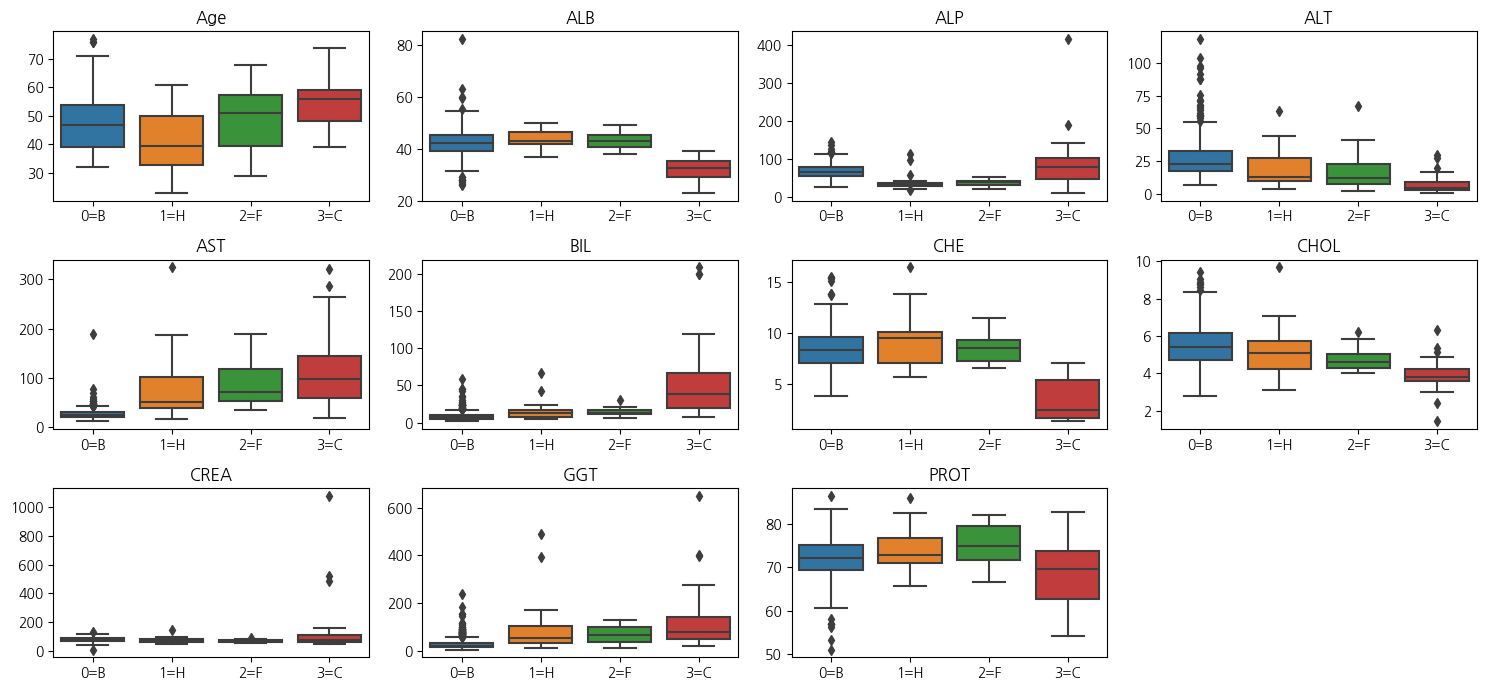

In [26]:
fig,axes = plt.subplots(3,4,figsize=(15,7))

target_col = ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE','CHOL', 'CREA', 'GGT', 'PROT']
for i,ax in enumerate(axes.flat[:-1]):
    target_df = df[['Category',target_col[i]]]
    sns.boxplot(x= 'Category',y = target_col[i] ,data = target_df, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(target_col[i])
    
axes.flat[-1].remove()
plt.tight_layout()
plt.show()

In [18]:
print('''간염 정도가 심각해질 수록, ALB,CHE,CHOL 평균 수치가 낮아짐을 확인 할 수 있으며, 
간염정도가 심각해질수록 AST,BIL,GGT 수치가 증가하고 있다. ''')

# ALB : 간에서 생성되는 단백질 
# ALP : 담즙 정체시 증가 
# ALT : 간세포가 손상되면 혈중으로 유출
# CHE : 간에서 생성되는 효소 
# CREA : 간 기능과 연관됨
# PROT : 혈장 내 단백질 총량

간염 정도가 심각해질 수록, ALB,CHE,CHOL 평균 수치가 낮아짐을 확인 할 수 있으며, 
간염정도가 심각해질수록 AST,BIL,GGT 수치가 증가하고 있다. 


# Y :범주형 별로 X: 연속형 변수

등분산 및 정규성을 확인하고 anova분석을 진행해도 좋을 듯.    
통계검정을 실시하라는 명시를 정확하게 주는 경우도 있고 차이를 확인하라고만도 표현하는 경우 있음   
이상치나 큰 차이가 시각화로 보이는 경우만 간단히 명시해줘도 괜찮아보입니다

In [28]:
df['Category'].unique()

array(['0=B', '1=H', '2=F', '3=C'], dtype=object)

In [27]:
from scipy.stats import shapiro, levene

columns_to_test = ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE','CHOL', 'CREA', 'GGT', 'PROT']
group_A = df[df['Category'] == '0=B']
group_B  = df[df['Category'] == '1=H']
group_C = df[df['Category'] == '0=B']
group_D  = df[df['Category'] == '1=H']


results = []

for col in columns_to_test:
    # 정규성 검정 (각 그룹)
    stat_A, p_A = shapiro(group_A[col])
    stat_B,  p_B  = shapiro(group_B[col])
    stat_C, p_C = shapiro(group_C[col])
    stat_D,  p_D  = shapiro(group_D[col])

    results.append({
        '변수': col,
        '정규성 group_A': round(p_A, 4),
        '정규성 group_B': round(p_B, 4),
        '정규성 group_C': round(p_C, 4),
        '정규성 group_D': round(p_D, 4),

    })

# 결과 출력
import pandas as pd
df_result = pd.DataFrame(results)
df_result

,변수,정규성 group_A,정규성 group_B,정규성 group_C,정규성 group_D
0,Age,0.0000,0.6424,0.0000,0.6424
1,ALB,0.0000,0.7733,0.0000,0.7733
2,ALP,0.0000,0.0000,0.0000,0.0000
3,ALT,0.0000,0.0036,0.0000,0.0036
4,AST,0.0000,0.0001,0.0000,0.0001
5,BIL,0.0000,0.0000,0.0000,0.0000
6,CHE,0.0001,0.0534,0.0001,0.0534
7,CHOL,0.0000,0.0407,0.0000,0.0407
8,CREA,0.0000,0.0007,0.0000,0.0007
9,GGT,0.0000,0.0000,0.0000,0.0000


In [43]:
print('''
정규성을 만족하지 않는 변수에 대해서 크루스왈리스 검정을 시행한다.
''')


정규성을 만족하지 않는 변수에 대해서 크루스왈리스 검정을 시행한다.



## 1-4 주어진 데이터로부터 주성분분석을 수행해 새로운 설명변수를 도출할 수 있는지를 검토 ∙ 판단한 뒤, 그 결과를 제시하시오

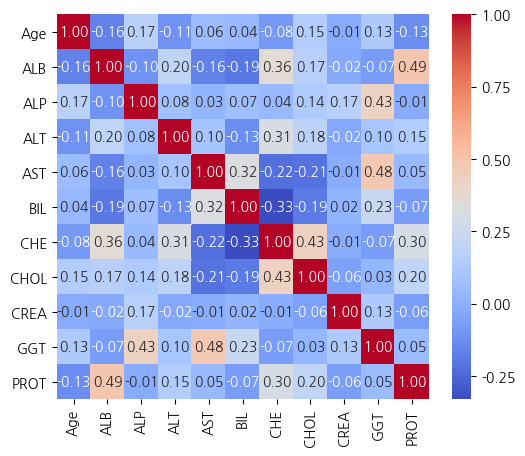

In [29]:
corr = df.drop('Category', axis =1).corr()

# 3. 히트맵 그리기
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()  # 변수간 상관관계를 보이지 않음

수치형 변수들에 대해서만 정규화를 진행하고 주성분분석을 진행한다

In [31]:
num = df.drop(columns =['Category','Sex']) # category, Sex 컬럼 제외

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

ss = StandardScaler()
num_scaled = ss.fit_transform(num)  

pca = PCA()
pca_fit = pca.fit(num_scaled)

pca_result = pd.DataFrame({'고유값': pca.singular_values_,\
              '분산 설명력': pca.explained_variance_ratio_,\
            '누적 분산 설명력':np.cumsum(pca.explained_variance_ratio_)})
print('주성분 분석 결과')
display(pca_result)

주성분 분석 결과


,고유값,분산 설명력,누적 분산 설명력
0,37.668811,0.221640,0.221640
1,32.385230,0.163824,0.385464
2,28.303095,0.125127,0.510592
3,25.030259,0.097862,0.608454
4,23.504640,0.086296,0.694750
5,20.896996,0.068211,0.762961
6,20.198784,0.063729,0.826689
7,18.966658,0.056191,0.882880
8,16.854372,0.044372,0.927252
9,16.579235,0.042935,0.970187


In [21]:
print('''
누적 분산설명력이 0.8을 넘기기 위해서는 7개의 주성분이 필요하다. 
주성분분석을 통한 차원축소의 효율이 높지 않다고 판단된다. 
그러므로 별도의 차원축소 없이 모델링을 진행한다.
''')


누적 분산설명력이 0.8을 넘기기 위해서는 7개의 주성분이 필요하다. 
주성분분석을 통한 차원축소의 효율이 높지 않다고 판단된다. 
그러므로 별도의 차원축소 없이 모델링을 진행한다.



## 2-1 데이터 불균형이 왜 문제인지 설명하고 불균형 해결방법에 대해 두가지를 설명하라

데이터 불균형은 종속변수의 특정 클래스 값이 다른 클래스 값에 비해 상대적으로 적은 경우를 의미한다.
대부분의 모델은 전체 정확도(accuracy)를 최대화하려고 하기 때문에 데이터가 많은 클래스에 편향되어 학습이 진행될 수 있다. 실제로 중요한 건 소수 클래스인데 이걸 못 잡으면 실무적으로 치명적 손실이 발생한다.  
1. 샘플링 기법  
오버샘플링과 언더샘플링으로 데이터 불균형을 해결할 수 있다. 
오버샘플링은 데이터가 적은 클래스의 데이터를 인위적으로 늘리는 방법이고, 언더샘플링은 데이터가 많은 클래스의 데이터를 줄이는 방법이다.    
오버샘플링은 과적합 위험, 언더샘플링은 정보 손실 가능성 존재 → 적절한 밸런싱 필요 
2. 클래스 가중치 조정  
분류 알고리즘에 class_weight=‘balanced’ 옵션 부여하여 손실 함수에 소수 클래스에 더 높은 페널티를 주어 학습 방향을 조정한다. 모델이 소수 클래스 오류에 더 민감하게 반응하도록 한다.

## 2-2 불균형 데이터 분류모델에 적합한 평가지표 3개 제시하고 그 이유 설명하라

소수 클래스가 존재하는 데이터셋에 대해서는 소수클래스를 잘 맞추었는지에 조금 더 관심을 두어야한다. 그것을 위해서 아래 3가지 지표를 활용할 수 있다.     
precision : 모델이 양성으로 예측한 데이터 중 실제로 양성인 데이터의 비율        
recall :  실제 양성 데이터 중에서 모델이 양성으로 올바르게 예측한 비율  
### 소수 클래스가 진짜 중요한 경우 → Recall이 더 중요
1. f1score 
- recall,precision의 조화평균, 두 지표간의 관계를 정량적 표현          
- 정밀도와 재현율을 동일하게 중요하게 여김  
2. f2score 
- Recall(재현율)을 Precision보다 더 중요하게 생각      

In [ ]:
from sklearn.metrics import fbeta_score

# β = 2 이면 F2-score
# f2 = fbeta_score(y_train, y_pred, beta=2, average='binary')

## 2-3 종속 변수를 정상(Category 0)과 비정상(Category 1,2,3)로 변경한 후 위의 2가지 불균형 처리 방법을 사용하고, 3가지 평가지표로 결과를 각각 평가하라.
(학습 규칙)
- 종속 변수를 이진화 후 불균형 처리 방법 진행
- 전처리 후 데이터 행의 index number를 초기화 하라(0부터 시작)
- index number 값이 5로 나눈 나머지가 0이라면 test, 그 외의 경우 train set으로 하여 진행
- 3가지 분류 모델을 사용하라

In [33]:
df2 = df.copy()

In [34]:
df2['Category']=df2['Category'].map({'0=B':0,'1=H':1,'2=F':1, '3=C':1})  # 정상과 비정상으로 변경

In [35]:
df2['Category'].value_counts()  # 클래스 별 분포, 불균형 데이터임을 확인

0    526
1     56
Name: Category, dtype: int64

In [36]:
df2['Sex'] = df2['Sex'].map({'m':1,'f':0}) # 범주형 변수 -> 수치화 (인코딩)

In [37]:
X = df2.drop("Category", axis = 1)  # 데이터 분할 
y = df2[['Category']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, \
                                                    stratify=y, random_state=42)

### 오버 샘플링 하지 않고, 분류 알고리즘에 가중치 조정

In [39]:
from sklearn.metrics import precision_score,recall_score,f1_score,fbeta_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("분류 알고리즘에 클래스 가중치 조절")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("F2-score:", fbeta_score(y_test, y_pred, beta=2))

분류 알고리즘에 클래스 가중치 조절
Precision: 1.0
Recall: 0.7142857142857143
F1-score: 0.8333333333333333
F2-score: 0.7575757575757576


### 오버 샘플링 SMOTE 진행

In [40]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state = 1, k_neighbors = 3)  # 이웃 수:  3
sm_X, sm_y = smote.fit_resample(X_train,y_train)
print(Counter(sm_y))

Counter({0: 394, 1: 394})


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score,recall_score,f1_score,fbeta_score

model1 = RandomForestClassifier(random_state=42)
model1.fit(sm_X, sm_y)
y_pred1 = model1.predict(X_test)

print("1. SMOTE 적용")
print("Precision:", precision_score(y_test, y_pred1))
print("Recall:", recall_score(y_test, y_pred1))
print("F1-score:", f1_score(y_test, y_pred1))
print("F2-score:", fbeta_score(y_test, y_pred1, beta=2))

1. SMOTE 적용
Precision: 1.0
Recall: 0.9285714285714286
F1-score: 0.962962962962963
F2-score: 0.9420289855072465


### 오버 샘플링 Kmeans SMOTE 진행

In [43]:
from imblearn.over_sampling import KMeansSMOTE

km = KMeansSMOTE(random_state = 1, k_neighbors = 3)

km_X, km_y = km.fit_resample(X_train, y_train)
print(Counter(km_y))  # 두개의 클래스 개수가 아예 같지 않아질 수 있음

Counter({1: 396, 0: 394})


In [44]:
model2 = RandomForestClassifier(random_state=42)
model2.fit(km_X, km_y)
y_pred2 = model2.predict(X_test)

print("2. KMeansSMOTE 적용")
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1-score:", f1_score(y_test, y_pred2))
print("F2-score:", fbeta_score(y_test, y_pred2, beta=2))

2. KMeansSMOTE 적용
Precision: 1.0
Recall: 0.7857142857142857
F1-score: 0.88
F2-score: 0.8208955223880596


## 3-1 1에서 전처리 완료한 데이터를 바탕으로 종속변수에서 0을 제외한 1,2,3의 데이터만 필터하여 분류모델 학습 및 평가를 진행하라. 
-> 셋 이상의 범주(class)**를 가지는 문제는 다중 분류(Multi-class Classification) 문제
(학습 규칙)
- 전처리 후 데이터 행의 index number를 초기화 하라(0부터 시작)
- index number 값이 5로 나눈 나머지가 0이라면 test, 그 외의 경우 train set으로 하여 진행
- 3개의 분류 모델을 사용하라

In [46]:
df3 = df.copy()
df3 = df3.loc[df3['Category'] != '0=B'].reset_index(drop= True)
df3['Category'] = df3['Category'].map({'1=H':1,'2=F':2, '3=C':3})
df3['Sex'] = df3['Sex'].map({'m':1,'f':0})
df3.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,23,1,47.0,19.1,38.9,164.2,17.0,7.09,3.20,79.3,90.4,70.1
1,1,25,1,42.0,38.2,63.3,187.7,14.0,6.00,4.28,66.9,40.2,70.5
2,1,27,1,45.0,27.5,10.5,37.8,10.0,8.77,3.20,55.2,35.9,74.5
3,1,32,1,45.0,34.6,44.3,96.2,16.0,10.11,6.28,81.2,48.1,82.1
4,1,32,1,41.0,34.4,12.1,60.9,6.0,13.80,5.48,45.4,33.1,71.1


In [47]:
df3['Category'].value_counts()   # 불균형 데이터 아님

3    24
1    20
2    12
Name: Category, dtype: int64

In [48]:
X = df3.drop("Category", axis = 1)
y = df3[['Category']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [49]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

In [50]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

# y_true: 실제 라벨, y_pred: 예측 라벨
# 4. 평가
print(f"Random Forest 정확도: {accuracy_score(y_test, y_pred_rfc):.4f}")
print(classification_report(y_test, y_pred_rfc))

Random Forest 정확도: 0.7857
              precision    recall  f1-score   support

           1       0.80      0.67      0.73         6
           2       0.33      0.50      0.40         2
           3       1.00      1.00      1.00         6

    accuracy                           0.79        14
   macro avg       0.71      0.72      0.71        14
weighted avg       0.82      0.79      0.80        14



- accuracy  
    • 전체 데이터 중에서 얼마나 맞췄는지
- macro avg  
	• 모든 클래스를 동일한 중요도로 간주하고 평균 낸 값
- weighted avg   
    • 클래스별 성능을 샘플 수 비중(weight)으로 평균  
    • 클래스 불균형 데이터셋에서는 주로 이걸 보고 판단함

## 다항 로지스틱 회귀 

In [147]:
#  일반 로지스틱 회귀는 이진 분류만 가능
#  다항 로지스틱 회귀는 클래스가 여러개 일때 확률을 구한다(Softmax 함수 이용)
#  -> 확률이 높은 클래스를 예측값으로 선택

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_z = scaler.fit_transform(X_train) 
X_test_z = scaler.transform(X_test)

In [52]:
X_train_z = pd.DataFrame(X_train_z, columns = X_train.columns)
X_test_z = pd.DataFrame(X_test_z, columns = X_test.columns)

In [53]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
lr.fit(X_train_z, y_train)

y_pred_lr = lr.predict(X_test_z)

# 4. 평가
print(f"로지스틱회귀 정확도: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

로지스틱회귀 정확도: 0.8571
              precision    recall  f1-score   support

           1       1.00      0.67      0.80         6
           2       0.50      1.00      0.67         2
           3       1.00      1.00      1.00         6

    accuracy                           0.86        14
   macro avg       0.83      0.89      0.82        14
weighted avg       0.93      0.86      0.87        14



In [54]:
from sklearn.svm import SVC

# SVM 모델 정의 및 학습
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_z, y_train)

# 3. 예측
y_pred_svm = svm.predict(X_test_z)

# 4. 평가
print(f"SVM 정확도: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\n분류 리포트:\n", classification_report(y_test, y_pred_svm))

SVM 정확도: 0.7143

분류 리포트:
               precision    recall  f1-score   support

           1       0.67      0.67      0.67         6
           2       0.33      0.50      0.40         2
           3       1.00      0.83      0.91         6

    accuracy                           0.71        14
   macro avg       0.67      0.67      0.66        14
weighted avg       0.76      0.71      0.73        14



## 3-2 학습한 모델 결과와 평가지표를 바탕으로 간염여부에 영향을 미치는 요소들에 대해 논의하라

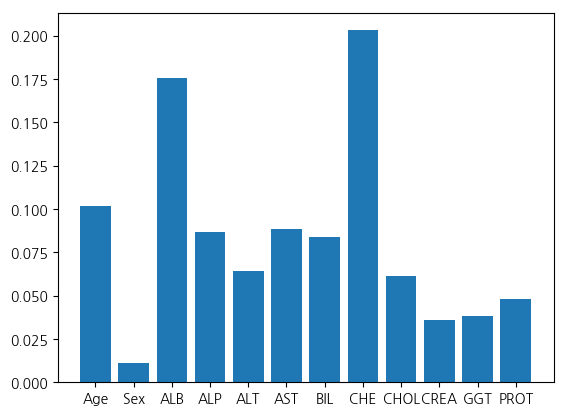

In [55]:
plt.bar(X.columns,rfc.feature_importances_)
plt.show()

# 적절히 모델 결과 해석과 트리류 모델 특징의 변수중요도 분석
# 랜덤포레스트 모델에서 CHE, ALB, Age 순으로 변수 중요도를 보인다.

### 다항 로지스틱 회귀에서 독립변수들의 영향 해석 -> 클래스 별로 회귀계수를 보고, 각 계수의 부호와 크기 그리고 오즈비로 해석 가능

In [56]:
import numpy as np
import pandas as pd

# 계수 확인
coef = lr.coef_  # shape: (n_classes, n_features)
odds_ratios = np.exp(coef)  # 오즈비로 해석

# 보기 좋게 출력
pd.DataFrame(odds_ratios, columns=X.columns, index=['Class 1', 'Class 2', 'Class 3']).T

,Class 1,Class 2,Class 3
Age,0.503631,1.364311,1.455373
Sex,1.142378,1.222197,0.716224
ALB,1.540043,1.690451,0.384118
ALP,1.034206,0.722087,1.339071
ALT,0.983459,1.053679,0.965018
AST,0.721251,1.273932,1.088347
BIL,1.305563,0.667833,1.146924
CHE,1.924451,1.796560,0.289235
CHOL,1.129706,0.971121,0.911510
CREA,0.978652,0.778206,1.313037


In [75]:
#  오즈비 해석:
#  값 > 1 → 해당 feature가 증가할수록 해당 클래스에 속할 오즈(odds)가 증가 (양의 영향)
#  값 < 1 → 해당 feature가 증가할수록 해당 클래스에 속할 오즈(odds)가 감소 (음의 영향)
#  값 ≈ 1 → 영향 거의 없음

# “변수 X가 1 단위 증가할 때, Class Y로 분류될 오즈는 Z배가 된다.”

#### 오즈비는 기준 클래스에 대한 상대적 비교이다. 기준 클래스 : Category = 1 인 Class 1

나이(Age): 1 단위 증가할수록 Class 2로 분류될 오즈는 약 1.703배 증가하므로,  
→ “고령일수록 간염 의심군(Class 2)에 속할 가능성이 높아진다”라고 해석할 수 있다.  
	•	ALT / ALP / AST: 간 수치 관련 변수로, 전반적으로 Class 3(간염 위험군)의 오즈가 높음   
→ “간 수치가 높을수록 간염 고위험군일 가능성이 높다”   
	•	ALB(알부민): Class 3에서 0.34 → “알부민 수치가 높아질수록 Class 3로 분류될 오즈 감소”  
→ 간 기능 저하를 나타낼 수 있음.   
	•	CHE: Class 2에서는 2.08 (높을수록 오즈 증가), Class 3에서는 0.31 (높을수록 오즈 감소)  
→ “CHE 수치는 중간 상태(Class 2)에서 높고, 위험군(Class 3)에서는 낮다”   

ALT의 오즈비는 1.35로, 1 단위 증가 시 간염 위험군(Class 2)에 분류될 오즈가 35% 증가하는 것으로 나타났다.   
반면, 알부민(ALB) 수치는 낮을수록 간염 위험군일 가능성이 높았으며, OR=0.34로 음의 영향을 보였다  

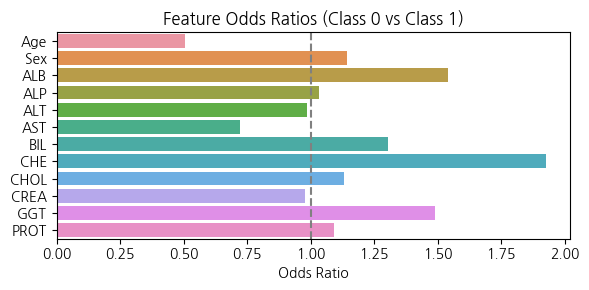

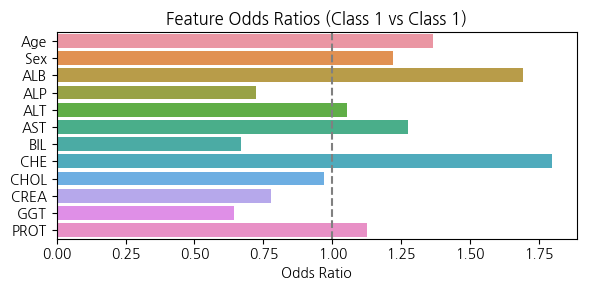

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns


for i, cls in enumerate(model.classes_):
    plt.figure(figsize=(6, 3))
    sns.barplot(x=odds_ratios[i], y=X.columns)
    plt.title(f'Feature Odds Ratios (Class {cls} vs Class 1)')
    plt.xlabel('Odds Ratio')
    plt.axvline(1.0, color='gray', linestyle='--')
    plt.tight_layout()
    plt.show()

## 4. 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15048032/fileData.do / 후처리, 통계청 날씨정보
- 데이터 링크 : 
    - ./data/p2_sb_2021.csv
    - ./data/p2_sb_2022.csv
    - ./data/p2_sb_2023.csv
    - ./data/p2_w_2021.csv
    - ./data/p2_w_2022.csv
    - ./data/p2_w_2023.csv
- 데이터 설명 : 
    - 21년~23년의 J시의 2개 지하철호선 지하철의 시간대별 승하차 인원 정보 데이터 (p2_sb_년도.csv)
        - X5~ X22 : 5시부터 22시 승차 또는 하차 인원, (X5 : 05시의 계절 날짜와 대응)
        - 역번호 : 각 정류장의 고유 번호
        - 승하차구분 : 승차 또는 하차
    - 21년~23년의 J시의 특정지역구의 시간대별 게절성 정보 데이터 (p2_w_년도.csv)
        - 시간별 J시의 날씨정보 

In [58]:
pd.set_option('display.max_columns', None)

In [1]:
import pandas as pd
p1 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_sb_2021.csv')
p2 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_sb_2022.csv')
p3 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_sb_2023.csv')

In [2]:
w1 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_w_2021.csv')
w2 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_w_2022.csv')
w3 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_w_2023.csv')

In [140]:
display(p1.head())
display(p2.head())
display(p3.head())
display(w1.head())
display(w2.head())
display(w3.head())

,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2021-01-01,A,201,승차,22.0,25,61,64,58,53,94,107,109,149,196,168,178,177,117,138,90,58
1,2021-01-01,A,201,하차,12.0,49,87,142,101,110,84,110,105,125,114,86,119,63,26,25,62,18
2,2021-01-01,A,202,승차,43.0,53,70,119,94,103,176,295,331,323,437,447,881,531,335,441,403,137
3,2021-01-01,A,202,하차,21.0,154,238,727,425,356,377,351,330,342,321,333,331,163,119,110,137,47
4,2021-01-01,A,203,승차,21.0,27,48,81,62,60,116,204,156,197,197,203,213,190,145,208,135,76


,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2022-01-01,A,201,승차,16.0,36,55,100,92,96,209,297,268,287,389,443,424,385,240,358,359,115
1,2022-01-01,A,201,하차,9.0,88,196,209,150,136,154,278,253,311,249,223,196,161,84,103,130,65
2,2022-01-01,A,202,승차,41.0,39,79,124,168,200,415,660,607,752,796,977,1377,1200,922,985,1094,417
3,2022-01-01,A,202,하차,38.0,156,220,707,564,529,630,762,776,801,828,837,861,649,328,245,403,176
4,2022-01-01,A,203,승차,24.0,36,72,70,105,263,280,554,439,413,409,395,497,475,377,581,689,212


,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2023-01-01,A,201,승차,43.0,43,43,138,140,287,392,602,482,527,601,627,761,801,581,507,503,304
1,2023-01-01,A,201,하차,36.0,126,144,245,283,348,332,418,403,432,450,371,354,308,227,232,237,208
2,2023-01-01,A,202,승차,108.0,111,120,175,278,556,881,1097,1154,1258,1372,1556,1687,1901,1347,1333,1162,1029
3,2023-01-01,A,202,하차,114.0,312,387,869,899,773,1121,1106,1252,1236,1145,1319,1289,1082,874,732,612,414
4,2023-01-01,A,203,승차,52.0,69,107,238,244,553,673,801,880,806,774,847,748,714,554,508,423,366


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2021-01-01 00:00,-8.3,NaN,1.8,66,2.2,1016.4,0.0,0,-6.8
1,2021-01-01 01:00,-8.7,NaN,2.4,68,2.2,1016.4,0.0,0,-6.9
2,2021-01-01 02:00,-9.1,NaN,1.6,69,2.1,1016.2,0.0,0,-7.1
3,2021-01-01 03:00,-9.3,NaN,1.1,70,2.1,1016.8,0.0,0,-7.3
4,2021-01-01 04:00,-9.3,NaN,0.3,71,2.2,1016.2,0.0,0,-7.5


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2022-01-01 00:00,-8.5,NaN,1.9,41,1.3,1021.9,0,0,-7.0
1,2022-01-01 01:00,-9.2,NaN,1.8,42,1.3,1022.2,0,0,-7.2
2,2022-01-01 02:00,-9.5,NaN,1.2,43,1.3,1022.3,0,0,-7.5
3,2022-01-01 03:00,-9.3,NaN,1.4,46,1.4,1022.6,0,0,-7.6
4,2022-01-01 04:00,-9.6,NaN,1.7,48,1.4,1021.9,0,0,-7.6


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2023-01-01 00:00,0.9,NaN,1.4,72,4.7,1018.5,9,9,-1.6
1,2023-01-01 01:00,1.5,NaN,1.9,71,4.9,1018.0,6,6,-1.4
2,2023-01-01 02:00,1.5,NaN,1.9,72,4.9,1017.8,9,8,-1.6
3,2023-01-01 03:00,1.6,NaN,1.6,74,5.1,1018.1,8,8,-1.8
4,2023-01-01 04:00,1.5,NaN,1.4,74,5.0,1018.1,9,9,-1.3


## 4-1 아래 조건들을 참고하여 전처리를 시행하고 훈련데이터에 대한 기초통계량을 구하시오
1. 승하차 데이터에서 X5~X22 모든컬럼이 0의 값을 가지는 경우 해당 날짜,호선,역번호 승하차 행은 제외한다. 
2. 승하차 데이터를 날짜,호선,역번호,시간대별(05~22시) 승객수의 총합을 구하여라(승차 + 하차), 결측치는 0명으로 간주한다. 컬럼명은 users로 변경한다.
3. 날짜 데이터의 강수 데이터는 결측치를 0, 그 외 컬럼의 결측치는 직전값으로 대치한다.
4. 날짜데이터와 일자,시간별 승하차인원 데이터를 동일날짜,시간에 대해 합친다.
5. 일자정보를 바탕으로 주말 여부를 나타내는 weekday컬럼을 추가한다. (주말=1,평일=0)
6. 21년,22년 데이터는 훈련데이터, 23년 데이터는 테스트 데이터로 사용한다.

In [10]:
p = pd.concat([p1,p2,p3], axis = 0).reset_index(drop = True)
w = pd.concat([w1,w2,w3], axis = 0).reset_index(drop = True)

In [14]:
p.head()

,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2021-01-01,A,201,승차,22.0,25,61,64,58,53,...,109,149,196,168,178,177,117,138,90,58
1,2021-01-01,A,201,하차,12.0,49,87,142,101,110,...,105,125,114,86,119,63,26,25,62,18
2,2021-01-01,A,202,승차,43.0,53,70,119,94,103,...,331,323,437,447,881,531,335,441,403,137
3,2021-01-01,A,202,하차,21.0,154,238,727,425,356,...,330,342,321,333,331,163,119,110,137,47
4,2021-01-01,A,203,승차,21.0,27,48,81,62,60,...,156,197,197,203,213,190,145,208,135,76


In [62]:
# 방법 1.
cols = [f'X{i}' for i in range(5, 23)]  # x5 형태의 열만 가져오기 
p = p[~(p[cols].sum(axis=1) == 0)]  # 열을 기준으로 (가로로 더함)
p = p.fillna(0)
p_melt = p.groupby(['날짜','호선','역번호'])[cols].sum().reset_index().melt(['날짜','호선','역번호'])
p_melt = p_melt.rename(columns ={'variable':'시간','value':'users'})
p_melt['시간']= p_melt['시간'].str.replace("X","")
p_melt['일시'] =  p_melt['날짜'].astype(str) + ' ' + p_melt['시간'].astype(str) + ':00'
p_melt['일시'] = pd.to_datetime(p_melt['일시'],format='%Y-%m-%d %H')
p_melt.drop(['날짜','시간'], axis =1, inplace= True )

In [63]:
p_melt

,호선,역번호,users,일시
0,A,201,34.0,2021-01-01 05:00:00
1,A,202,64.0,2021-01-01 05:00:00
2,A,203,39.0,2021-01-01 05:00:00
3,A,204,23.0,2021-01-01 05:00:00
4,A,205,67.0,2021-01-01 05:00:00
...,...,...,...,...
1636231,B,338,373.0,2023-12-31 22:00:00
1636232,B,339,976.0,2023-12-31 22:00:00
1636233,B,340,287.0,2023-12-31 22:00:00
1636234,B,341,256.0,2023-12-31 22:00:00


In [142]:
# 방법 2.
p = p[p.iloc[:,4:].sum(axis = 1) != 0].reset_index(drop= True) # 열 기준으로 가로로 더함
p = p.fillna(0)
p = p.drop(columns = ['승하차구분']).groupby(['날짜','호선','역번호']).sum().reset_index()
p_melt = p.melt(['날짜','호선','역번호']).rename(columns ={'variable':'시간','value':'users'})
p_melt['시간']= p_melt['시간'].str.replace("X","")
p_melt['일시'] =  p_melt['날짜'].astype(str) + ' ' + p_melt['시간'].astype(str) + ':00' # Y-m-d H:M 까지는 형태 필요
p_melt['일시'] = pd.to_datetime(p_melt['일시'],format='%Y-%m-%d %H')
p_melt.drop(['날짜','시간'], axis =1, inplace= True )

In [107]:
# 방법 1과 2중 아무거나 실행해서 밑에 진행

In [64]:
w['강수량'] =w['강수량'].fillna(0)
w = w.sort_values("일시").fillna(method = 'ffill')
w['일시'] = pd.to_datetime(w['일시'],format='%Y-%m-%d %H')

In [65]:
df = pd.merge(p_melt, w)
df['주말여부']=0
df.loc[(df['일시'].dt.weekday == 5)|(df['일시'].dt.weekday == 6),'주말여부'] = 1

df['month'] = df['일시'].dt.month
df['day'] = df['일시'].dt.day
df['hour'] = df['일시'].dt.hour

df['호선'] = df['호선'].map({'A':1},{'B': 0}).fillna(0).astype(int)
df['호선'] = df['호선'].astype("category")
df['역번호'] = df['역번호'].astype("category")
df['주말여부'] = df['주말여부'].astype("category")

In [66]:
train = df[(df['일시'].dt.year == 2021)|(df['일시'].dt.year == 2022)].reset_index(drop= True)
test = df[(df['일시'].dt.year == 2023)].reset_index(drop= True)

In [67]:
train.describe().T # 이걸 보여주는 것이 문제 1이었음

,count,mean,std,min,25%,50%,75%,max
users,1090620.0,2093.877278,2346.067281,0.0,597.000,1347.0,2732.0,26183.0
기온,1090620.0,14.176355,11.175155,-18.5,6.000,15.4,23.6,36.3
강수량,1090620.0,0.171750,1.440923,0.0,0.000,0.0,0.0,64.7
풍속,1090620.0,2.481560,1.134005,0.0,1.700,2.3,3.1,8.6
습도,1090620.0,62.749391,18.919553,17.0,48.000,62.0,78.0,100.0
증기압,1090620.0,12.654094,8.796690,0.7,5.375,9.9,19.7,35.2
현지기압,1090620.0,1005.940944,8.094596,984.1,999.400,1006.3,1012.3,1025.8
전운량,1090620.0,4.974505,3.956197,0.0,0.000,6.0,9.0,10.0
중하층운량,1090620.0,3.064764,3.459133,0.0,0.000,1.0,7.0,10.0
지면온도,1090620.0,16.311941,13.159712,-12.7,5.100,17.1,25.7,59.8


In [68]:
train.describe(include = 'category')

,호선,역번호,주말여부
count,1090620,1090620,1090620
unique,2,83,2
top,1,342,0
freq,657000,13140,778374


## 4-2 전체 년도 데이터에 대해 users와 날씨 정보에 대해 상관관계를 분석하고 주말여부에 따른 users 변수의 차이가 존재하는지 통계적으로 확인하라.

In [69]:
df

,호선,역번호,users,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도,주말여부,month,day,hour
0,1,201,34.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
1,1,202,64.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
2,1,203,39.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
3,1,204,23.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
4,1,205,67.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1636231,0,338,373.0,2023-12-31 22:00:00,1.3,0.0,0.6,95,6.3,1014.1,0.0,0,-0.2,1,12,31,22
1636232,0,339,976.0,2023-12-31 22:00:00,1.3,0.0,0.6,95,6.3,1014.1,0.0,0,-0.2,1,12,31,22
1636233,0,340,287.0,2023-12-31 22:00:00,1.3,0.0,0.6,95,6.3,1014.1,0.0,0,-0.2,1,12,31,22
1636234,0,341,256.0,2023-12-31 22:00:00,1.3,0.0,0.6,95,6.3,1014.1,0.0,0,-0.2,1,12,31,22


In [149]:
display(df.drop(columns = ['호선','역번호','일시']).corr()['users'][1:].sort_values())
print("계절컬럼의 상관계수는 users와 큰 관계가 없다. 주말여부와 약한 음의 상관관계를 보인다.")

습도      -0.051947
중하층운량   -0.013331
현지기압    -0.011956
전운량     -0.008708
강수량     -0.003306
증기압      0.000272
day      0.011626
지면온도     0.023862
month    0.032211
기온       0.032292
풍속       0.051441
hour     0.096264
Name: users, dtype: float64

계절컬럼의 상관계수는 users와 큰 관계가 없다. 주말여부와 약한 음의 상관관계를 보인다.


In [71]:
from scipy.stats import shapiro, levene

group_A = df[df['주말여부'] == 0]
group_B  = df[df['주말여부'] == 1]


results = []

stat_A, p_A = shapiro(group_A['users'])
stat_B,  p_B  = shapiro(group_B['users'])
results.append({
    '변수': 'users',
    '정규성 group_A': round(p_A, 4),
    '정규성 group_B': round(p_B, 4),
    })

# 결과 출력
import pandas as pd
df_result = pd.DataFrame(results)
df_result

,변수,정규성 group_A,정규성 group_B
0,users,0.0,0.0


In [72]:
# 등분산성 검정 (Levene's test)
stat_levene, p_levene = levene(group_A['users'], group_B['users'])

# 결과 추가
df_result['등분산성 (Levene p-value)'] = round(p_levene, 4)

# 결과 출력
df_result

,변수,정규성 group_A,정규성 group_B,등분산성 (Levene p-value)
0,users,0.0,0.0,0.0


In [73]:
# 등분산성 검정 (Levene's test)
stat_levene, p_levene = levene(group_A['users'], group_B['users'])

# 결과 추가
df_result['등분산성 (Levene p-value)'] = round(p_levene, 4)

# 결과 출력
df_result

,변수,정규성 group_A,정규성 group_B,등분산성 (Levene p-value)
0,users,0.0,0.0,0.0


**3.	적절한 검정 선택**
   - 정규성 O + 등분산성 O → 독립표본 t-test
   - 정규성 O + 등분산성 X → Welch’s t-test
   - 정규성 X (둘 중 하나라도) → Mann-Whitney U test

In [74]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(group_A['users'], group_B['users'], alternative='two-sided')

print(f"Mann-Whitney U 검정 통계량: {stat:.4f}")
print(f"p-value: {p:.4f} → {'통계적으로 유의한 차이 있음' if p < 0.05 else '유의한 차이 없음'}")

Mann-Whitney U 검정 통계량: 347858575963.5000
p-value: 0.0000 → 통계적으로 유의한 차이 있음


## 4-3 users를 예측하는 2가지 회귀모델을 학습하고 모델에 대해 평가하라 (선형회귀 모델은 1개 필수 포함)

In [75]:
train = train.sample(10000)  # 데이터 개수 100만개 -> 너무 오래 걸려서 샘플링, 시험에서는 이런 이슈는 없을겁니다.
drop_col = ['일시','users']

train_x = train.drop(columns = drop_col)
train_y = train['users']

test_x = test.drop(columns = drop_col)
test_y = test['users']

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# 표준화 진행 
ss =StandardScaler()
train_x_ss = ss.fit_transform(train_x)
test_x_ss = ss.transform(test_x)

# 모델링 객체 생성 
rf =  RandomForestRegressor(random_state=1)
lr =  LinearRegression()  

# 훈련 및 예측
rf.fit(train_x_ss,train_y)  
lr.fit(train_x_ss,train_y)
pred_rf = rf.predict(test_x_ss)
pred_lr = lr.predict(test_x_ss)

# 평가 (R2, RMSE)
r2_rf = r2_score(test_y,pred_rf)
r2_lr = r2_score(test_y,pred_lr)

rf_mse = mean_squared_error(test_y, pred_rf)
lr_mse = mean_squared_error(test_y, pred_lr)

result = pd.DataFrame([[r2_rf,rf_mse],[r2_lr, lr_mse]],index=['랜덤포레스트','선형회귀'],columns=['R2','RMSE'])
result

# 역번호, 시간 등 적절한 전처리를 하지 않아도 강건한 랜덤포레스트에서 좀 더 좋은 결과가 나왔다.

,R2,RMSE
랜덤포레스트,0.808002,1.289491e+06
선형회귀,0.096914,6.065287e+06


# 통계 (40점)

## 데이터 설명
- 데이터 출처 : 자체 제작
- 데이터 링크 : ./data/s1.csv
- 데이터 설명 : A,B 두 공장의 특정 일자의 수율(%)데이터. 단, 불량률은 (100 - 수율)로 정의한다.
    

In [98]:
df = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/s1.csv')
df.head()

,year,month,day,A,B
0,2023,Sep,7,56.9,42.3
1,2023,Feb,20,100.0,89.0
2,2023,Jun,15,19.3,59.0
3,2023,Apr,11,98.0,84.8
4,2023,Jul,8,89.5,63.8


In [99]:
df.isnull().sum()

year     0
month    0
day      0
A        5
B        5
dtype: int64

In [100]:
df = df.dropna()

## 5-1 공장별 불량률 차이 평균, 표준편차를 제시하시오.

In [101]:
df['불량률_A'] = 100 - df['A']
df['불량률_B'] = 100 - df['B']

In [103]:
df

,year,month,day,A,B,불량률_A,불량률_B
0,2023,Sep,7,56.9,42.3,43.1,57.7
1,2023,Feb,20,100.0,89.0,0.0,11.0
2,2023,Jun,15,19.3,59.0,80.7,41.0
3,2023,Apr,11,98.0,84.8,2.0,15.2
4,2023,Jul,8,89.5,63.8,10.5,36.2
5,2023,Feb,21,42.5,78.0,57.5,22.0
6,2023,Feb,7,98.3,52.3,1.7,47.7
8,2023,Mar,19,60.3,72.1,39.7,27.9
10,2023,Feb,11,84.2,99.9,15.8,0.1
11,2023,Mar,11,52.4,81.7,47.6,18.3


In [88]:
# # 2. 날짜 기준 병합
# merged = pd.merge(
#     df_A[['year', 'month', 'day', '불량률']],
#     df_B[['year', 'month', 'day', '불량률']],
#     on=['year', 'month', 'day'],
#     suffixes=('_A', '_B')
# )
# merged.head()

In [104]:
# 3. 불량률 차이 계산 (B - A)
df['불량률차이'] = df['불량률_B'] - df['불량률_A']

# 4. 평균과 표준편차 계산
mean_diff = df['불량률차이'].mean()
std_diff = df['불량률차이'].std()

print(f'두 공장의 불량률 차이 평균: {mean_diff:.2f}')  # 공장 B가 A보다 평균적으로 불량률이 3.56% 더 높거나 낮다
print(f'두 공장의 불량률 차이 표준편차: {std_diff:.2f}')  # 차이의 변동성

두 공장의 불량률 차이 평균: 5.27
두 공장의 불량률 차이 표준편차: 22.34


## 5-2 A,B 공장의 불량률 평균 차이가 존재하는지 확인하려 한다. 귀무,대립 가설을 설정하고 설명하라

In [105]:
# 정규성 등분산성 검정 

from scipy.stats import shapiro, levene

# A, B 공장 불량률 데이터
a_defect = df['불량률_A']
b_defect = df['불량률_B']

# 1. 정규성 검정
stat_a, p_a = shapiro(a_defect)
stat_b, p_b = shapiro(b_defect)

print("정규성 검정 (Shapiro-Wilk)")
print(f"A공장: p-value = {p_a:.4f} → {'정규성 만족' if p_a >= 0.05 else '정규성 불만족'}")
print(f"B공장: p-value = {p_b:.4f} → {'정규성 만족' if p_b >= 0.05 else '정규성 불만족'}")

# # 2. 등분산성 검정
# stat_levene, p_levene = levene(a_defect, b_defect)
# print("\n등분산성 검정 (Levene's Test)")
# print(f"p-value = {p_levene:.4f} → {'등분산성 만족' if p_levene >= 0.05 else '등분산성 불만족'}")

정규성 검정 (Shapiro-Wilk)
A공장: p-value = 0.0083 → 정규성 불만족
B공장: p-value = 0.6152 → 정규성 만족

등분산성 검정 (Levene's Test)
p-value = 0.0189 → 등분산성 불만족


In [ ]:
# 정규성 만족 못하니 맨휘트니
# 두 공장의 불량률 분포는 같다
# 두 공장의 불량률 분포는 다르다.

## 5-3 A,B의 차이가 있는지 통계검정 하고 설명하라

In [106]:
from scipy.stats import mannwhitneyu

# 두 그룹 불량률
a_defect = df['불량률_A']
b_defect = df['불량률_B']

# Mann-Whitney U 검정 (양측검정)
stat, p_value = mannwhitneyu(a_defect, b_defect, alternative='two-sided')

print("Mann-Whitney U 검정 결과")
print(f"U 통계량: {stat:.4f}")
print(f"p-value : {p_value:.4f}")

# 해석
if p_value < 0.05:
    print("귀무가설 기각 → 두 공장의 불량률 분포는 **통계적으로 유의하게 다르다**.")
else:
    print("귀무가설 채택 → 두 공장의 불량률 분포는 **유의미한 차이가 없다**.")

Mann-Whitney U 검정 결과
U 통계량: 630.5000
p-value : 0.1038
귀무가설 채택 → 두 공장의 불량률 분포는 **유의미한 차이가 없다**.


## 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15123586/fileData.do 후처리
- 데이터 링크 : ./data/s2.csv
- 데이터 설명 : 일자별 지하철 노션별 지연 데이터

In [67]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/s2.csv')
df

,지연ID,지연일자,노선,최대지연시간
0,ID_0,2023-09-01,1호선,15분
1,ID_1,2023-09-01,1호선,15분
2,ID_2,2023-09-01,4호선,10분
3,ID_3,2023-09-01,4호선,10분
4,ID_4,2023-09-04,4호선,10분
...,...,...,...,...
828,ID_828,2024-08-28,4호선,15분
829,ID_829,2024-08-29,4호선,10분
830,ID_830,2024-08-29,4호선,10분
831,ID_831,2024-08-30,4호선,10분


## 6-1 노선에 상관없이 일별 최대 지연시간이 5~15분으로 발생하는 경우는 하나의 사건으로 보자. 해당 사건이 일자별 발생하는 빈도가 푸아송분포를 따르는지 확인하는 방법 2가지를 기술하고 결과를 보여라

In [32]:
# 지하철 1호선의 일일 총 연착 횟수가 포아송 분포를 따른다고 할 수 있는지 검정하시오.

In [31]:
# 카이제곱 적합도 검정 (Chi-square Goodness-of-Fit Test)
# (귀무가설): 데이터는 포아송 분포를 따른다.
# (대립가설): 데이터는 포아송 분포를 따르지 않는다.

In [44]:
import pandas as pd
import numpy as np
from scipy.stats import poisson, chisquare, kstest
import matplotlib.pyplot as plt
import seaborn as sns


# 1. 전처리: 날짜별로 '5~15분' 지연이 있으면 1건의 사건으로 간주
df['발생여부'] = df['최대지연시간'].str.replace('분', '').str.replace(' 이상', '').astype(int).between(5, 15).astype(int)
df.head()

,지연ID,지연일자,노선,최대지연시간,발생여부
0,ID_0,2023-09-01,1호선,15분,1
1,ID_1,2023-09-01,1호선,15분,1
2,ID_2,2023-09-01,4호선,10분,1
3,ID_3,2023-09-01,4호선,10분,1
4,ID_4,2023-09-04,4호선,10분,1


In [41]:
df.groupby('노선')['최대지연시간'].value_counts().to_frame()

최대지연시간
노선  최대지연시간        
1호선 10분        142
    5분         127
    15분         36
    20분         31
    25분          9
    30분 이상       7
4호선 10분        272
    15분        117
    5분          52
    20분         27
    25분          7
    30분 이상       6

In [45]:
df.groupby('노선')['발생여부'].value_counts().to_frame()

발생여부
노선  발생여부      
1호선 1      305
    0       47
4호선 1      441
    0       40

In [47]:
# 2. 날짜별 사건 발생 횟수 세기
daily_counts = df[df['발생여부'] == 1].groupby('지연일자').size()

# 전체 날짜 목록 만들기 (지연 없던 날도 포함시키기 위해)
all_dates = pd.date_range(start=df['지연일자'].min(), end=df['지연일자'].max())
daily_counts = daily_counts.reindex(all_dates.strftime('%Y-%m-%d'), fill_value=0)
print(all_dates)
print(daily_counts)

DatetimeIndex(['2023-09-01', '2023-09-02', '2023-09-03', '2023-09-04',
               '2023-09-05', '2023-09-06', '2023-09-07', '2023-09-08',
               '2023-09-09', '2023-09-10',
               ...
               '2024-08-21', '2024-08-22', '2024-08-23', '2024-08-24',
               '2024-08-25', '2024-08-26', '2024-08-27', '2024-08-28',
               '2024-08-29', '2024-08-30'],
              dtype='datetime64[ns]', length=365, freq='D')
2023-09-01    4
2023-09-02    0
2023-09-03    0
2023-09-04    2
2023-09-05    3
             ..
2024-08-26    2
2024-08-27    2
2024-08-28    2
2024-08-29    2
2024-08-30    2
Length: 365, dtype: int64


In [62]:
# λ 추정 (사건 평균 발생 수)
lambda_ = daily_counts.mean()

In [63]:
# ---------------------------
# 방법 2. KS 검정 or 시각화
# ---------------------------
stat_ks, p_ks = kstest(daily_counts, cdf='poisson', args=(lambda_,))
print(f"\n[Kolmogorov-Smirnov 검정]")
print(f"KS 통계량 = {stat_ks:.3f}, p-value = {p_ks:.4f}") # 귀무가설 기각하여 포아송 분포를 따르지 않는다.


[Kolmogorov-Smirnov 검정]
KS 통계량 = 0.309, p-value = 0.0000


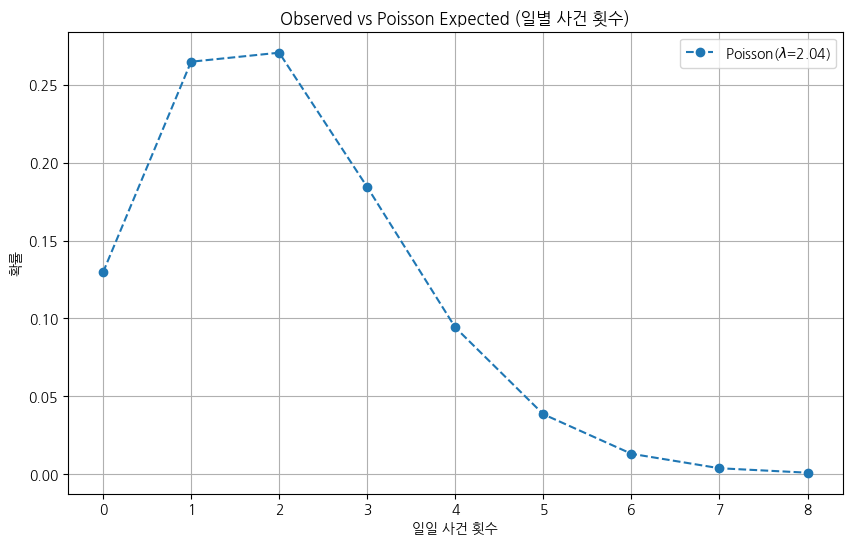

In [64]:
# ---------------------------
# 시각화 (히스토그램 vs 포아송)
# ---------------------------
plt.figure(figsize=(10,6))
x = np.arange(0, daily_counts.max() + 1)
plt.plot(x, poisson.pmf(x, mu=lambda_), marker='o', linestyle='--', label='Poisson($\lambda$={:.2f})'.format(lambda_))
plt.title('Observed vs Poisson Expected (일별 사건 횟수)')
plt.xlabel('일일 사건 횟수')
plt.ylabel('확률')
plt.legend()
plt.grid()
plt.show()

## 6-2 10분이하, 10분초과 -20분 이하, 20분초과  3가지로 지연시간을 지연정도로 분류하라. 호선별 지연정도를 교차표로 구하여라

In [68]:
# 호선변 지연정도 
df['최대지연시간'] = df['최대지연시간'].str.replace('분', '').str.replace(' 이상', '').astype(int)
df.head()

,지연ID,지연일자,노선,최대지연시간
0,ID_0,2023-09-01,1호선,15
1,ID_1,2023-09-01,1호선,15
2,ID_2,2023-09-01,4호선,10
3,ID_3,2023-09-01,4호선,10
4,ID_4,2023-09-04,4호선,10


In [69]:
# 2. 지연정도 분류
def classify_delay(mins):
    if mins <= 10:
        return '10분 이하'
    elif mins <= 20:
        return '10~20분'
    else:
        return '20분 초과'

df['지연정도'] = df['최대지연시간'].apply(classify_delay)

In [72]:
# 3. 교차표 생성 (호선별 x 지연정도)
cross_tab = pd.crosstab(df['노선'], df['지연정도'])

# 4. 결과 확인
display(cross_tab)

지연정도,10~20분,10분 이하,20분 초과
노선,,,
1호선,67,269,16
4호선,144,324,13


## 6-3 지하철 호선별로 지연정도가 차이가 있는지 확인하려한다. 귀무가설과 대립가설을 설정한 후 통계 검정을 실시하라

In [ ]:
# 카이제곱 동립성 검정 
# 귀무가설 : 지하철 호선별로 지연정도에 차이가 없다 
# 대립가설 : 지하철 호선별로 지연정도에 차이가 있다. 

In [73]:
# 카이제곱 독립성 검정 
from scipy.stats import chi2_contingency

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(cross_tab)
print(f"카이제곱 검정통계량 : {chi2:.3f}, 유의확률 : {p:.3f}") # 귀무가설을 기각하여 지하철 호선별로 지연정도에 차이가 있다.

카이제곱 검정통계량 : 13.866, 유의확률 : 0.001


## 데이터 설명
- 데이터 출처 : 자체제작
- 데이터 링크 : ./data/s3.csv
- 데이터 설명 : 시계열 정보를 가지는 250행의 데이터

In [54]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/s3.csv'\
                 , header=None)
df.columns = ['time']
df.head()

,time
0,0.496714
1,0.308778
2,0.692133
3,2.070861
4,1.326845


In [56]:
df['time'].max()

4.594591691648733

## 7-1 ar ma arma에 대해 설명하고, ACF, PACF는 패턴을 통해 설명하라.

- AR(p) : 자기회귀모형으로 과거값들의 선형결합으로 이루어져있다. 
- MA(q) : 이동평균 모델로 과거의 오차항 결합이다. 
- ARMA(p,q) : AR과 MA를 합친 모델이다. 

- AR(p): PCAF 그래프에서 p 시점 이후 급격히 0으로 감소하는 패턴을 보이며 
- MA(q) : ACF 그래프에서 q 시점 이후 급격히 0으로 감소하는 패턴을 보인다.
- ARMA(p,q)는 두 그래프 모두에서 감쇠하는 형태를 보인다.

## 7-2 Acf pacf를 그리고 해석하라, 해당 Plot data를 기반으로 ARMA(p,q)모형 제시하라

# 정상성 확인 

In [65]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

In [67]:
result = adfuller(df['time'])
print(f"ADF 통계량: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("유의수준 0.05하에 귀무가설을 기각하여 정상성 시계열이라는 결론을 얻었다. ")

ADF 통계량: -5.6150
p-value: 0.0000
유의수준 0.05하에 귀무가설을 기각하여 정상성 시계열이라는 결론을 얻었다. 


In [68]:
# 따라서 AR(p)모형 / MA(q) / ARMA(p,q) 모형이 된다.

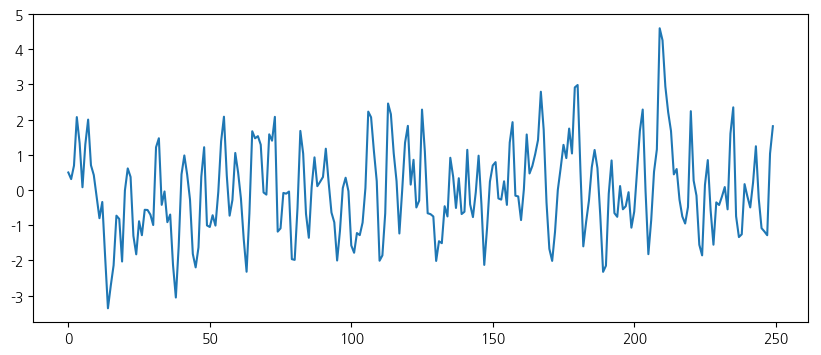

In [70]:
plt.figure(figsize=(10, 4))
plt.plot(df['time'])
plt.show()  # 정상성을 만족한다.

<Figure size 1200x1200 with 0 Axes>

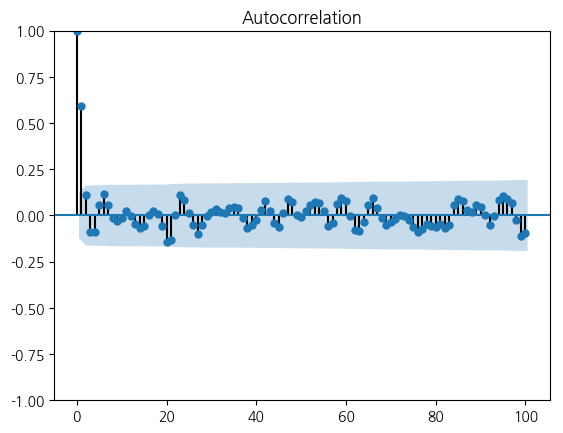

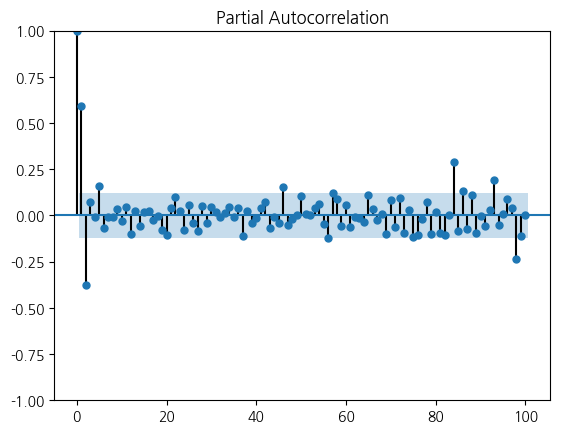

In [62]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,12))
plot_acf(df['time'], lags = 100)
plot_pacf(df['time'], lags = 100)
plt.show()

In [63]:
# ACF 그래프에서 q = 1시점 이후로 급격히 0으로 감소하며 , PCAF 그래프에서 p = 2 시점 이후로 급격히 0으로 감소하는 것을 볼 수 있다.

In [72]:
# 따라서 ARIMA(2,0,1) 모형으로 모델을 적합시킨다. 
model = ARIMA(df['time'],order = (2,0,1))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                   time   No. Observations:                  250
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -345.443
Date:                Fri, 25 Apr 2025   AIC                            700.887
Time:                        22:52:38   BIC                            718.494
Sample:                             0   HQIC                           707.973
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0051      0.122     -0.042      0.966      -0.244       0.233
ar.L1          0.6199      0.172      3.613      0.000       0.284       0.956
ar.L2         -0.2538      0.120     -2.115      0.0

# 최적화

In [71]:
from pmdarima import auto_arima

auto_model = auto_arima(df['time'], seasonal=False, stepwise=True)
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  250
Model:               SARIMAX(3, 0, 1)   Log Likelihood                -343.103
Date:                Fri, 25 Apr 2025   AIC                            696.207
Time:                        22:50:06   BIC                            713.814
Sample:                             0   HQIC                           703.293
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0126      0.129     -0.098      0.922      -0.265       0.240
ar.L2          0.2665      0.124      2.149      0.032       0.023       0.510
ar.L3         -0.2442      0.092     -2.646      0.0